In [1]:
import numpy as np
import glob
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
)
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# --- Load Embeddings and Labels ---
save_dir = '/Users/muhammad/Desktop/tabert_embeddings'

embedding_files = sorted(glob.glob(f"{save_dir}/embeddings_batch_*.npy"))
label_files = sorted(glob.glob(f"{save_dir}/labels_batch_*.npy"))




In [2]:
X = np.concatenate([np.load(f) for f in embedding_files])
y = np.concatenate([np.load(f) for f in label_files])


In [4]:
X

array([[-0.2068945 , -0.31610754,  0.5902721 , ..., -0.2195861 ,
        -0.3202929 , -0.0338821 ],
       [-0.19659285, -0.3146029 ,  0.58121854, ..., -0.21296205,
        -0.3094548 , -0.03755488],
       [-0.17687659, -0.32364547,  0.5739284 , ..., -0.21684653,
        -0.3055504 , -0.05465369],
       ...,
       [-0.2125648 , -0.32318106,  0.62342393, ..., -0.21852122,
        -0.33036605, -0.0360654 ],
       [-0.2125648 , -0.3231811 ,  0.623424  , ..., -0.21852125,
        -0.33036605, -0.03606542],
       [-0.21256483, -0.32318106,  0.623424  , ..., -0.21852127,
        -0.33036608, -0.03606544]], dtype=float32)

In [112]:
y_binary = (y == 0.0).astype(int)

In [98]:
X.shape

(1, 36, 512)

In [120]:

y_binary = np.array([
    1 if label == 'Benign' else
    2 if label == 'Fuzzers' else
    0 for label in y
])

In [121]:

def evaluate(y_true, y_pred, model_name, y_scores=None):
    print(f"\n📊 Evaluation for {model_name}")

    n_classes = len(np.unique(y_true))
    average_type = 'binary' if n_classes == 2 else 'macro'

    # Accuracy and Classification Metrics
    print("Accuracy          :", accuracy_score(y_true, y_pred))
    print("Precision         :", precision_score(y_true, y_pred, average=average_type, zero_division=0))
    print("Recall            :", recall_score(y_true, y_pred, average=average_type, zero_division=0))
    print("F1-Score          :", f1_score(y_true, y_pred, average=average_type, zero_division=0))
    print("Macro F1-Score    :", f1_score(y_true, y_pred, average='macro', zero_division=0))
    print("Micro F1-Score    :", f1_score(y_true, y_pred, average='micro', zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred, zero_division=0))

    # ROC-AUC and Precision-Recall Curve
    if y_scores is not None:
        try:
            if n_classes == 2:
                auc = roc_auc_score(y_true, y_scores)
                precision, recall, _ = precision_recall_curve(y_true, y_scores)
                plt.plot(recall, precision, label=f"{model_name} (AUC = {auc:.2f})")
                print("ROC-AUC Score     :", auc)
            # For Multiclass Classification (n_classes > 2)
            else:
                # Plot PR curve for each class in a one-vs-rest fashion
                for i in range(n_classes):
                    precision, recall, _ = precision_recall_curve(y_true == i, y_scores[:, i])
                    plt.plot(recall, precision, label=f"Class {i} (PR Curve)")

                # Calculate Multiclass ROC-AUC (One-vs-Rest style)
                auc = roc_auc_score(y_true, y_scores, multi_class='ovr', average='macro')
                print("Multiclass ROC-AUC (macro, ovr):", auc)

        except Exception as e:
            print("⚠️ ROC-AUC or PR Curve could not be plotted:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
3

📊 Evaluation for KNN
Accuracy          : 0.14285714285714285
Precision         : 0.05555555555555555
Recall            : 0.16666666666666666
F1-Score          : 0.08333333333333333
Macro F1-Score    : 0.08333333333333333
Micro F1-Score    : 0.14285714285714285
Confusion Matrix:
 [[2 2 0]
 [9 0 0]
 [1 0 0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.17      0.50      0.25         4
           1       0.00      0.00      0.00         9
           2       0.00      0.00      0.00         1

    accuracy                           0.14        14
   macro avg       0.06      0.17      0.08        14
weighted avg       0.05      0.14      0.07        14

⚠️ ROC-AUC or PR Curve could not be plotted: too many indices for array: array is 1-dimensional, but 2 were indexed

📊 Evaluation for Isolation Forest
Accuracy          : 0.14285714285714285
Precision         : 0.05555555555555555
Recall         

/var/folders/g0/1hy0d4f569x4rzb1vxlv3d880000gn/T/ipykernel_73659/513641990.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


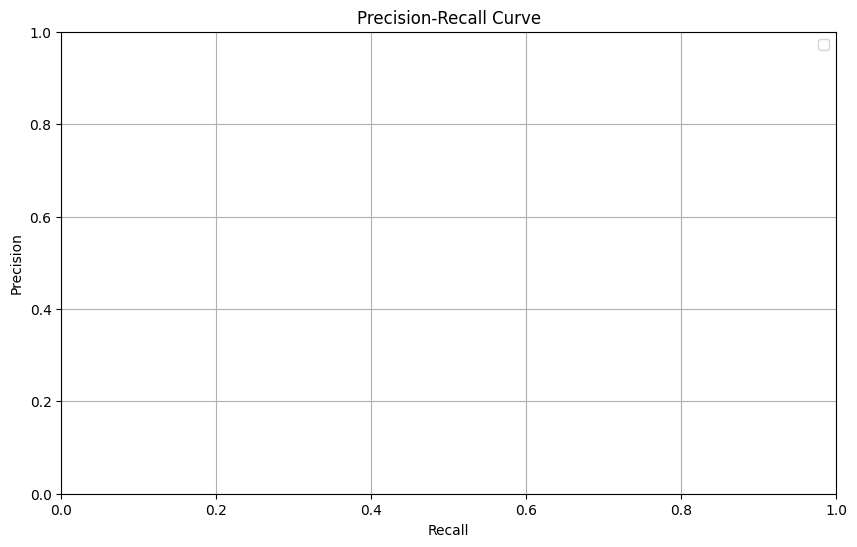

In [122]:
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.3, random_state=42)
results = {}

# --- 1. KNN ---
knn = NearestNeighbors(n_neighbors=5)
knn.fit(X_train)
dists, _ = knn.kneighbors(X_test)
knn_scores = dists[:, -1]
knn_preds = (knn_scores > np.percentile(knn_scores, 90)).astype(int)
results["KNN"] = (knn_preds, knn_scores)

# --- 2. Isolation Forest ---
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_train)
iso_scores = -iso.decision_function(X_test)
iso_preds = (iso_scores > np.percentile(iso_scores, 90)).astype(int)
results["Isolation Forest"] = (iso_preds, iso_scores)

# --- 3. LOF ---
lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
lof.fit(X_train)
lof_scores = -lof.decision_function(X_test)
lof_preds = (lof_scores > np.percentile(lof_scores, 90)).astype(int)
results["LOF"] = (lof_preds, lof_scores)

# --- 4. PCA Reconstruction ---
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
X_test_recon = pca.inverse_transform(X_test_pca)
pca_scores = np.mean((X_test - X_test_recon)**2, axis=1)
pca_preds = (pca_scores > np.percentile(pca_scores, 90)).astype(int)
results["PCA"] = (pca_preds, pca_scores)

# --- 5. One-Class SVM ---
svm = OneClassSVM(kernel="rbf", nu=0.1, gamma='scale')
svm.fit(X_train)
svm_scores = -svm.decision_function(X_test)
svm_preds = (svm_scores > np.percentile(svm_scores, 90)).astype(int)
results["One-Class SVM"] = (svm_preds, svm_scores)

# --- 6. Autoencoder ---
def build_autoencoder(input_dim):
    inp = Input(shape=(input_dim,))
    x = Dense(64, activation='relu')(inp)
    x = Dense(32, activation='relu')(x)
    bottleneck = Dense(16, activation='relu')(x)
    x = Dense(32, activation='relu')(bottleneck)
    x = Dense(64, activation='relu')(x)
    out = Dense(input_dim, activation='linear')(x)
    return Model(inp, out)

auto = build_autoencoder(X.shape[1])
auto.compile(optimizer=Adam(1e-3), loss='mse')
auto.fit(X_train, X_train, epochs=20, batch_size=32, verbose=0, validation_split=0.1)
X_test_recon = auto.predict(X_test)
ae_scores = np.mean((X_test - X_test_recon)**2, axis=1)
ae_preds = (ae_scores > np.percentile(ae_scores, 90)).astype(int)
results["Autoencoder"] = (ae_preds, ae_scores)


print(len(np.unique(y_test)))
# ------- Evaluate All Models -------
plt.figure(figsize=(10, 6))
for model_name, (preds, scores) in results.items():
    
    evaluate(y_test, preds, model_name, scores)

# --- Show PR Curve ---
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
y_score = 0.4
val_score = 0.003
threshold = 0.038  # or compute it dynamically: np.mean(y_train)

# Apply threshold to scores
y_pred = int(y_score >= threshold)
val_pred = int(val_score >= threshold)
print(f"Predicted: {y_pred}, Validation Predicted: {val_pred}") 

Predicted: 1, Validation Predicted: 0


(1860000,)